# Understanding activation functions with pure python
activation functions with pure python

In [6]:
# 1. sigmoid activation function
import math
def sigmoid(x):
    return 1/(1+math.exp(-x))
sigmoid(0)

0.5

# 2. NumPy Implementation (Vectorized & Scalable)

NumPy optimizes this process through a concept called vectorization. By replacing math.exp with np.exp, the exact same formula can seamlessly process scalar values, 1D vectors, and massive multi-dimensional matrices simultaneously without slow for loops

In [8]:
import numpy as np
def numpy_sigmoid(x):
    return 1/(1+np.exp(-x))
numpy_sigmoid(0)

np.float64(0.5)

# testing our function  different inputs shape

In [11]:
input_vector=np.array([-2, -1, 0, 1, 2])
print(input_vector)
print(numpy_sigmoid(input_vector))

[-2 -1  0  1  2]
[0.11920292 0.26894142 0.5        0.73105858 0.88079708]


# Test 3: 2D Array (Matrix / Batch of data)

In [12]:
input_matrix=np.array([[-1,1], [-2, 2]])
print(numpy_sigmoid(input_matrix))

[[0.26894142 0.73105858]
 [0.11920292 0.88079708]]


# 3. Visualizing the Behavior

Using numpy_sigmoid paired with Matplotlib, you can see the classic S-shaped curve (logistic curve) that gives the function its name.

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
x=np.linspace(-10, 10, 100)
y=numpy_sigmoid(x)
df=pd.DataFrame(x, y)

df


,0
0.000045,-10.000000
0.000056,-9.797980
0.000068,-9.595960
0.000083,-9.393939
0.000102,-9.191919
...,...
0.999898,9.191919
0.999917,9.393939
0.999932,9.595960
0.999944,9.797980


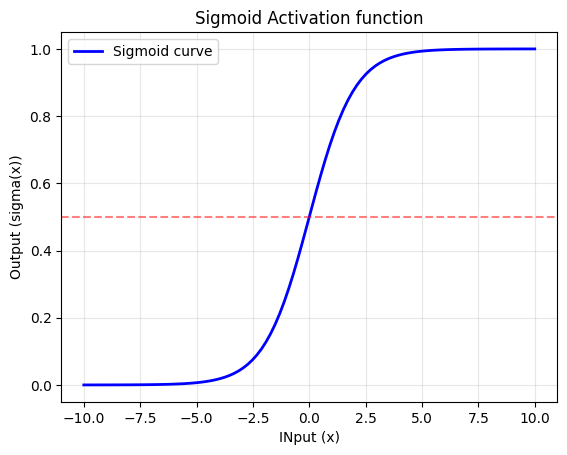

In [17]:
# plotting the curve
plt.plot(x, y, label="Sigmoid curve", color="blue", linewidth=2)
plt.axhline(0.5, color="red", linestyle="--", alpha=0.5)
plt.title("Sigmoid Activation function")
plt.xlabel("INput (x)")
plt.ylabel("Output (sigma(x))")
plt.grid(True, alpha=0.3)
plt.legend()


## The softmax activation function
turns a vector of raw numbers (called logits) into a probability distribution. Unlike the sigmoid function which handles numbers individually, softmax is multiclass: it scales all numbers in an array so that they fall between 0 and 1, and all numbers combined add up to exactly 1

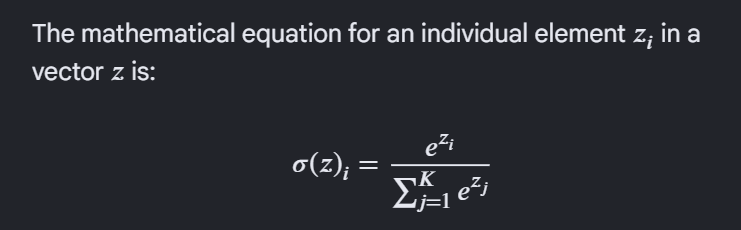

## 1. Pure Python Implementation (Single List)
In vanilla Python, you can loop through the list to calculate the exponents and sum them up.

In [19]:
def basic_softmax(logits):
    # calculate e^x for every value
    exp_logits=[math.exp(x) for x in logits]
    # step 2: sum all the exponents together
    sum_exp_logits=sum(exp_logits)
    return [exp/sum_exp_logits for exp  in exp_logits ]

# Testing with 3 class scores
logits=[2.0, 1.0, 0.1]
print(basic_softmax(logits))

[0.6590011388859679, 0.2424329707047139, 0.09856589040931818]


## 2. NumPy Implementation (Vectorized & Stable)

In real-world machine learning, raw scores can be very large numbers. Calculating \(e^{1000}\) will cause a RuntimeWarning: overflow encountered in exp in Python.To fix this, we use a trick called Numerically Stable

Softmax. We subtract the maximum value in the array from all elements before taking the exponent. This does not change the final probabilities but prevents numbers from exploding.

In [22]:
import numpy as np

def stable_softmax(z):
    # subtracting the max value prevent overflow (numerical stability)
    exp_z=np.exp(z-np.max(z, axis=-1, keepdims=True))
    return exp_z/np.sum(exp_z, axis=-1, keepdims=True)
# test 1: standard vector
vector=np.array([2.0, 1.0, 0.1])
print(stable_softmax(vector))

# test 2: Hadnling huge numbers smoothly to stability trick
huge_vector=np.array([1000.0, 999.0, 998.1])
print(stable_softmax(huge_vector))
# Output is identical to test 1 instead of crashing

    

[0.65900114 0.24243297 0.09856589]
[0.65900114 0.24243297 0.09856589]


# Plot 2: Softmax Probabilities

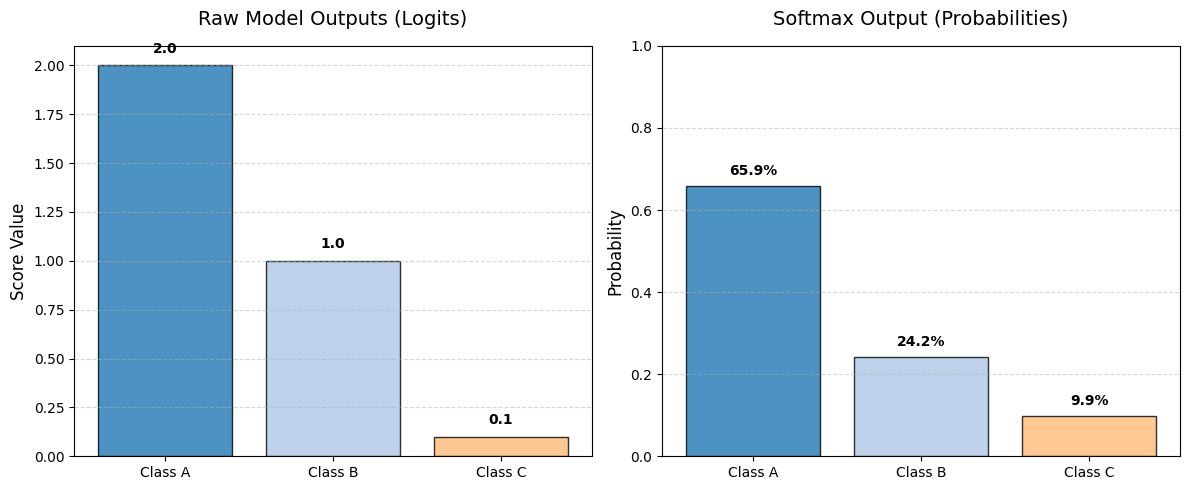

In [26]:
classes = ['Class A', 'Class B', 'Class C']
logits = np.array([2.0, 1.0, 0.1])

# 2. Calculate probabilities using softmax
probabilities = stable_softmax(logits)


# 3. Create the side-by-side subplot figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# Plot 1: Raw Logits
colors = ['#1f77b4', '#aec7e8', '#ffbb78']
bars1 = ax1.bar(classes, logits, color=colors, edgecolor='black', alpha=0.8)
ax1.set_title("Raw Model Outputs (Logits)", fontsize=14, pad=15)
ax1.set_ylabel("Score Value", fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.1f}", ha='center', va='bottom', fontweight='bold')

# Plot 2: Softmax Probabilities
bars2 = ax2.bar(classes, probabilities, color=colors, edgecolor='black', alpha=0.8)
ax2.set_title("Softmax Output (Probabilities)", fontsize=14, pad=15)
ax2.set_ylabel("Probability", fontsize=12)
ax2.set_ylim(0, 1.0) # Probabilities always fall between 0 and 1
ax2.grid(axis='y', linestyle='--', alpha=0.5)


# Add percentage labels on top of bars
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval*100:.1f}%", ha='center', va='bottom', fontweight='bold')

# Adjust layout and display the charts
plt.tight_layout()
plt.show()